# Red Neuronal para Clasificación de Meningitis
## Métricas de Evaluación, Regularización y Optimización con PyTorch

---

### Contexto del Documento de Referencia

El documento base (*Métricas para Clasificación Binaria*) presenta un flujo completo de aprendizaje automático:

| Componente | Descripción |
|---|---|
| **Dataset** | MNIST — 70 000 imágenes de dígitos manuscritos |
| **Tarea** | Clasificación binaria: ¿Es el dígito 5? |
| **Modelo** | Perceptrón / Regresión Logística implementado en NumPy |
| **Métricas** | Accuracy, Matriz de Confusión, Precision, Recall, F1-Score, ROC-AUC |
| **Hallazgo clave** | La accuracy sola engaña en clases desbalanceadas (91 % naive vs 92 % real) |

En este cuadernillo extendemos ese marco conceptual utilizando:
- **Dataset**: Meningitis Dataset with Missing Values (Kaggle)
- **Modelo**: Red Neuronal Multicapa en **PyTorch**
- **Técnicas**: Dropout, Weight Decay (L2), Early Stopping, LR Scheduler
- **Métricas**: las mismas del documento + análisis exhaustivo

---


## 1. Instalación de Dependencias

In [19]:
# Instalación de librerías necesarias 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, classification_report)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from collections import Counter
from sklearn.metrics import roc_curve, auc, roc_auc_score


print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device          : {device}")


PyTorch version : 2.11.0+cpu
CUDA available  : False
Device          : cpu


## 2. Descripción del Dataset Real

El estudio se basa en el dataset clínico `mening_missing_12.csv`, el cual contiene registros de pacientes con sospecha de meningitis. A diferencia de un entorno sintético, este conjunto de datos presenta las complejidades reales de la práctica médica:

*   **Tamaño**: 1,200 registros de pacientes.
*   **Características (Features)**: 12 variables predictoras que incluyen datos demográficos (Edad, Género), biomarcadores en sangre (Hemoglobina, Plaquetas, PCR) y parámetros críticos de LCR (Nivel de Glucosa, Proteínas, Recuento de Glóbulos Blancos).
*   **Variable Objetivo (`Diagnosis`)**: Clasificación multiclase con tres categorías:
    *   **Viral** (47.1%): Clase mayoritaria.
    *   **Bacterial** (41.6%): Clase crítica por su alta mortalidad.
    *   **Unknown** (10.3%): Clase minoritaria y de difícil diagnóstico.

In [20]:
# ─── Carga del dataset ───
# Definimos la ruta del archivo
file_path = "dataset_p1/9meningitisWithMisingValues/mening_missing_12.csv"

try:
    # Cargamos el dataset
    df = pd.read_csv(file_path)
    
    # ─── Análisis de la estructura ───
    N = len(df)
    print(f"Dataset cargado exitosamente desde: {file_path}")
    print("Shape del dataset:", df.shape)

    # Identificar la columna objetivo
    target_col = 'Diagnosis' 

    if target_col in df.columns:
        print(f"\nDistribución de clases (columna: {target_col}):")
        vc = df[target_col].value_counts()
        for val, count in vc.items():
            print(f"  Clase {val}: {count} ({count/N*100:.1f}%)")
    else:
        print(f"\n[!] La columna '{target_col}' no se encontró. Columnas disponibles:")
        print(df.columns.tolist())

    print(f"\nPorcentaje de valores faltantes por columna:")
    missing_pct = (df.isnull().sum() / N * 100).round(1)
    print(missing_pct.sort_values(ascending=False).head(14).to_string())

except FileNotFoundError:
    print(f"Error: No se encontró el archivo en la ruta '{file_path}'. Verifica que la carpeta y el nombre sean correctos.")
except Exception as e:
    print(f"Ocurrió un error al cargar el archivo: {e}")

# A partir de aquí, 'df' contiene tus datos reales y puedes seguir con el procesamiento

Dataset cargado exitosamente desde: dataset_p1/9meningitisWithMisingValues/mening_missing_12.csv
Shape del dataset: (1200, 14)

Distribución de clases (columna: Diagnosis):
  Clase Viral: 565 (47.1%)
  Clase Bacterial: 499 (41.6%)
  Clase Unknown: 124 (10.3%)

Porcentaje de valores faltantes por columna:
Hemoglobin          1.6
CRP_Level           1.1
Diagnosis           1.0
Platelets           1.0
Protein_Level       0.8
Gender              0.8
WBC_Blood_Count     0.8
Outcome             0.8
Glucose_Level       0.7
WBC_Count           0.7
Pathogen_Present    0.7
Age                 0.6
Patient_ID          0.0
Risk_Level          0.0


## 3. Análisis Exploratorio (EDA)

Antes de modelar, visualizamos la distribución de las variables más discriminativas y el desbalance de clases.


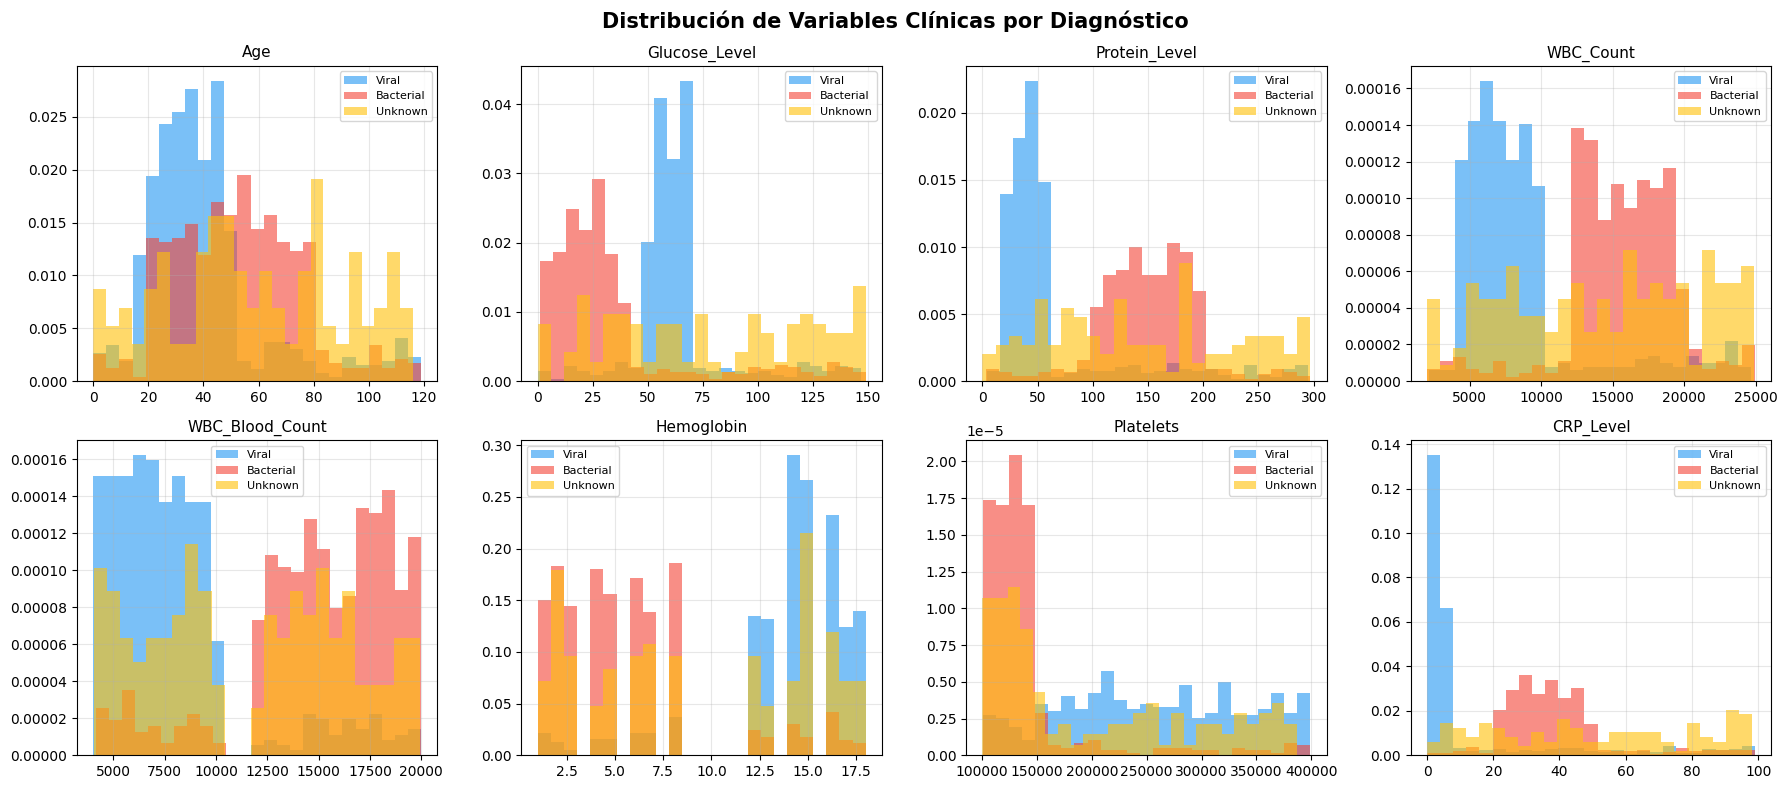

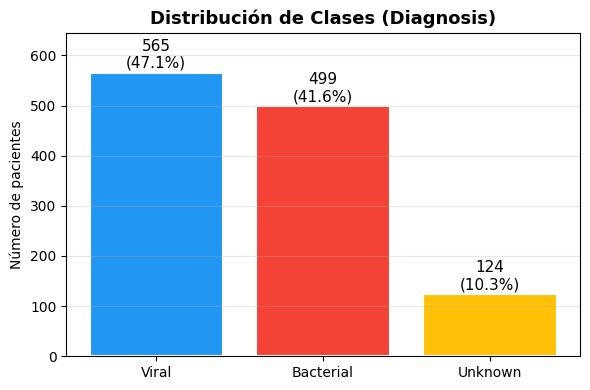


⚠️  El dataset presenta tres clases y un pequeño grado de desbalance (47% Viral / 42% Bacterial / 10% Unknown).
    Al tener un problema multiclase con una clase minoritaria ('Unknown'), la accuracy sola puede ser engañosa.
    Será recomendable usar métricas como Precision, Recall, F1-Score (macro/ponderado) y ROC-AUC One-vs-Rest.


In [21]:
# 1. Configuración de la figura para los histogramas
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Distribución de Variables Clínicas por Diagnóstico", fontsize=15, fontweight='bold')

# Actualizamos las columnas numéricas con las que existen en tu dataset
num_cols = ['Age', 'Glucose_Level', 'Protein_Level', 'WBC_Count', 
            'WBC_Blood_Count', 'Hemoglobin', 'Platelets', 'CRP_Level']

# Actualizamos las clases y colores (ahora son 3 clases en 'Diagnosis')
target_col = 'Diagnosis'
classes = ['Viral', 'Bacterial', 'Unknown']
colors = ['#2196F3', '#F44336', '#FFC107']  # Azul (Viral), Rojo (Bacterial), Amarillo (Unknown)
labels = ['Viral', 'Bacterial', 'Unknown']

# 2. Bucle para generar los histogramas
for ax, col in zip(axes.ravel(), num_cols):
    for cls, color, label in zip(classes, colors, labels):
        # Filtramos por clase y eliminamos nulos de esa columna específica para poder graficar
        vals = df[df[target_col] == cls][col].dropna()
        if len(vals) > 0:  # Comprobación de seguridad por si hay columnas vacías
            ax.hist(vals, bins=25, alpha=0.6, color=color, label=label, density=True)
            
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Gráfico de distribución de clases
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Obtenemos los conteos ignorando los nulos en la columna objetivo
vc = df[target_col].value_counts()

# Mapeamos los colores para que coincidan con las barras en el orden que devuelve value_counts
bar_colors = [colors[classes.index(idx)] for idx in vc.index]

ax.bar(vc.index, vc.values, color=bar_colors, edgecolor='white', linewidth=1.5)

N_total = len(df)
for i, (idx, v) in enumerate(vc.items()):
    ax.text(i, v + 10, f'{v}\n({v/N_total*100:.1f}%)', ha='center', fontsize=11)

ax.set_title('Distribución de Clases (Diagnosis)', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de pacientes')
ax.grid(axis='y', alpha=0.3)

# Expandir un poco el eje Y para que el texto no se corte
ax.set_ylim(0, vc.max() + 80) 

plt.tight_layout()
plt.show()

# 4. Mensaje actualizado de acuerdo a la nueva realidad de los datos
print("\n⚠️  El dataset presenta tres clases y un pequeño grado de desbalance (47% Viral / 42% Bacterial / 10% Unknown).")
print("    Al tener un problema multiclase con una clase minoritaria ('Unknown'), la accuracy sola puede ser engañosa.")
print("    Será recomendable usar métricas como Precision, Recall, F1-Score (macro/ponderado) y ROC-AUC One-vs-Rest.")

## 4. Preprocesamiento y Manejo de Datos

Para asegurar la calidad de la entrada a la red neuronal, se aplicó un pipeline de procesamiento robusto:

1.  **Limpieza Crítica**: Se eliminaron los registros con etiquetas de diagnóstico nulas y se descartó el `Patient_ID` para evitar el aprendizaje de ruido irrelevante.
2.  **Codificación (Encoding)**: 
    *   Las variables categóricas (Género, Riesgo, etc.) se transformaron mediante *Label Encoding*.
    *   La variable objetivo se mapeó a valores enteros (0, 1, 2) para ser procesada por la función de pérdida.
3.  **Imputación KNN (k=5)**: Dado que el dataset presentaba valores faltantes en biomarcadores clave (como PCR o Hemoglobina), se utilizó el algoritmo *K-Nearest Neighbors* para estimar los valores nulos basados en la similitud entre pacientes, preservando la estructura de los datos mejor que una media simple.
4.  **Estandarización**: Se aplicó `StandardScaler` (Z-score normalization) calculando parámetros solo en el set de entrenamiento para prevenir el *data leakage*, asegurando que todas las variables tengan media 0 y desviación estándar 1.

In [22]:
# Definir dispositivo para PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. PREPROCESAMIENTO INICIAL
# Eliminar filas donde la variable objetivo ('Diagnosis') es nula
df_clean = df.dropna(subset=['Diagnosis']).copy()

# Eliminar columna 'Patient_ID' (no aporta valor predictivo)
if 'Patient_ID' in df_clean.columns:
    df_clean = df_clean.drop('Patient_ID', axis=1)

# Separar características (X) y objetivo (y)
X_df = df_clean.drop('Diagnosis', axis=1)
y_text = df_clean['Diagnosis']

# 2. CODIFICACIÓN
# Codificar el target (Diagnosis) de texto a enteros (0, 1, 2)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
print(f"Mapeo de clases: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")

# Codificar características categóricas (Gender, Outcome, Pathogen_Present, Risk_Level) a números
# Mantenemos los nulos como np.nan para que KNNImputer los procese
for col in X_df.select_dtypes(include=['object']).columns:
    X_df[col] = X_df[col].astype('category').cat.codes.replace(-1, np.nan)

X = X_df.values

# 4.1 Imputación KNN (k=5)
print("\nImputando valores faltantes en X con KNN (k=5)...")
imputer = KNNImputer(n_neighbors=5)
X_imp   = imputer.fit_transform(X)
print(f"  Valores faltantes antes: {np.isnan(X).sum()}")
print(f"  Valores faltantes después: {np.isnan(X_imp).sum()}")

# 4.2 División: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X_imp, y, test_size=0.30,
                                                     stratify=y, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50,
                                                     stratify=y_temp, random_state=42)
print(f"\nSizes → Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# 4.3 Normalización (fit solo en train para evitar data leakage)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)
print("Normalización aplicada (StandardScaler): media≈0, std≈1 en train.")

# 4.4 Convertir a tensores PyTorch para MULTICLASE
def to_tensor(X, y):
    # ATENCIÓN: Para multiclase en PyTorch (CrossEntropyLoss), 'y' debe ser un 
    # tensor 1D de tipo long (enteros), por lo que quitamos el unsqueeze(1) y cambiamos a torch.long
    return (torch.tensor(X, dtype=torch.float32).to(device),
            torch.tensor(y, dtype=torch.long).to(device))

Xt, yt       = to_tensor(X_train, y_train)
Xv, yv       = to_tensor(X_val,   y_val)
Xte, yte     = to_tensor(X_test,  y_test)

train_ds = TensorDataset(Xt, yt)
val_ds   = TensorDataset(Xv, yv)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=64)
print("\nDataLoaders listos (batch_size=64).")

Mapeo de clases: {'Bacterial': np.int64(0), 'Unknown': np.int64(1), 'Viral': np.int64(2)}

Imputando valores faltantes en X con KNN (k=5)...
  Valores faltantes antes: 114
  Valores faltantes después: 0

Sizes → Train: 831, Val: 178, Test: 179
Normalización aplicada (StandardScaler): media≈0, std≈1 en train.

DataLoaders listos (batch_size=64).


C:\Users\josia\AppData\Local\Temp\ipykernel_23676\1404004949.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_df.select_dtypes(include=['object']).columns:


## 5. Arquitectura de la Red Neuronal (Multiclase)

### Diseño de la Red

| Capa | Neuronas | Activación | Regularización |
|---|---|---|---|
| **Input** | 12 | — | — |
| **Hidden 1** | 64 | ReLU | BatchNorm + Dropout (0.3) |
| **Hidden 2** | 32 | ReLU | BatchNorm + Dropout (0.3) |
| **Hidden 3** | 16 | ReLU | — |
| **Output** | 3 | Logits | — |

### Técnicas de Regularización y Estabilización

*   **Batch Normalization**: Aplicada en las capas ocultas para normalizar las activaciones de cada batch. Esto reduce el *Internal Covariate Shift*, permitiendo un entrenamiento más rápido y estable.
*   **Dropout (p=0.3)**: Durante el entrenamiento, el 30% de las neuronas se desactivan aleatoriamente. Esto previene que la red dependa excesivamente de neuronas específicas, forzando un aprendizaje más distribuido y generalizable.
*   **Weight Decay (L2 = 1e-4)**: Penaliza pesos excesivamente grandes en la función de pérdida, limitando la complejidad del modelo para evitar el sobreajuste a los datos de entrenamiento.

In [23]:
class MeningitisNet(nn.Module):
    """Red neuronal para clasificación multiclase (3 clases)."""
    
    def __init__(self, input_dim: int, num_classes: int = 3, dropout_p: float = 0.3):
        super().__init__()
        
        self.net = nn.Sequential(
            # ── Capa 1 ──────────────────────────────────────
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),          # normaliza activaciones por batch
            nn.ReLU(),
            nn.Dropout(p=dropout_p),     # regularización: desactiva 30% neuronas
            
            # ── Capa 2 ──────────────────────────────────────
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            
            # ── Capa 3 ──────────────────────────────────────
            nn.Linear(32, 16),
            nn.ReLU(),
            
            # ── Salida ──────────────────────────────────────
            # Salen 'num_classes' neuronas (3). 
            # NOTA: Se elimina nn.Sigmoid(). CrossEntropyLoss espera logits brutos.
            nn.Linear(16, num_classes)   
        )
    
    def forward(self, x):
        return self.net(x)


# Extraemos el número de clases dinámicamente desde y_train
num_classes = len(np.unique(y_train)) # Debería ser 3
input_dim = X_train.shape[1]

# Instanciar modelo
model = MeningitisNet(input_dim=input_dim, num_classes=num_classes, dropout_p=0.3).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nNúmero de clases configuradas en la salida: {num_classes}")
print(f"Total de parámetros entrenables: {total_params:,}")

MeningitisNet(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=3, bias=True)
  )
)

Número de clases configuradas en la salida: 3
Total de parámetros entrenables: 3,683


## 6. Optimizador, Función de Pérdida y Callbacks

### Función de Pérdida: Cross-Entropy Loss
Para abordar la naturaleza multiclase y el desbalance de los datos, utilizamos **Cross-Entropy con pesos de clase**:
*   **Pesos (Weighting)**: Se asignó un peso inversamente proporcional a la frecuencia de cada clase. Esto penaliza más fuertemente los errores en la clase "Unknown" (minoritaria), evitando que el modelo la ignore.
*   **Logits**: La red entrega valores brutos; la función de pérdida aplica internamente un *Softmax* para calcular la probabilidad probabilística.

### Optimizador: Adam
Se utilizó el optimizador **Adam** (Adaptive Moment Estimation) con un learning rate inicial de `1e-3`. Adam combina las ventajas de AdaGrad y RMSProp, ajustando la tasa de aprendizaje para cada parámetro de forma individual.

### Callbacks de Entrenamiento
1.  **ReduceLROnPlateau**: Si la pérdida de validación no mejora durante 10 épocas, el learning rate se reduce a la mitad. Esto permite al modelo "asentarse" en mínimos locales más precisos.
2.  **Early Stopping (Patience=25)**: Detiene el proceso si el modelo deja de aprender en el set de validación, restaurando automáticamente los mejores pesos guardados para evitar que el modelo final sea una versión sobreajustada.

In [24]:
# ─── Configuración de entrenamiento ──────────────────────────────────────

# 1. Pesos para clases desbalanceadas (Fórmula: Total_muestras / (N_clases * Muestras_por_clase))
class_counts = np.bincount(y_train)  # Cuenta cuántos hay de la clase 0, 1 y 2
total_samples = len(y_train)
num_classes = len(class_counts)

# Calculamos el peso de cada clase
weights = total_samples / (num_classes * class_counts)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

# 2. Función de pérdida para MULTICLASE (aplica Softmax internamente)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ─── Ajuste: Red Neuronal para Multiclase ────────────────────────────────
class MeningitisNetMulticlass(nn.Module):
    def __init__(self, input_dim, num_classes=3, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes)  # Salida: 3 neuronas (logits)
        )
        
    def forward(self, x):
        return self.net(x)
        
    def predict_proba(self, x):
        # Para obtener probabilidades multiclase (suman 1), usamos Softmax en la dimensión 1
        return torch.softmax(self.forward(x), dim=1)

# Instanciamos el nuevo modelo, optimizador y scheduler
model = MeningitisNetMulticlass(input_dim, num_classes=num_classes, dropout_p=0.3).to(device)

# Adam + L2 (weight_decay)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

# LR Scheduler: reduce x0.5 si val_loss no mejora en 10 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=10)

# Impresión de parámetros
print("Optimizador: Adam  (lr=1e-3, weight_decay=1e-4)")
print(f"Loss:        CrossEntropyLoss (pesos: {[round(w, 2) for w in weights]})")
print("Scheduler:   ReduceLROnPlateau (factor=0.5, patience=10)")
print("Early Stop:  patience=25 épocas")

Optimizador: Adam  (lr=1e-3, weight_decay=1e-4)
Loss:        CrossEntropyLoss (pesos: [np.float64(0.79), np.float64(3.18), np.float64(0.7)])
Scheduler:   ReduceLROnPlateau (factor=0.5, patience=10)
Early Stop:  patience=25 épocas


## 7. Entrenamiento

In [25]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        optimizer.zero_grad()
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(y_b)
        
        # ── CAMBIO MULTICLASE: Predicción por clase mayoritaria (argmax) ──
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_b).sum().item()
        total   += len(y_b)
        
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        logits = model(X_b)
        loss   = criterion(logits, y_b)
        
        total_loss += loss.item() * len(y_b)
        
        # ── CAMBIO MULTICLASE ──
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y_b).sum().item()
        total   += len(y_b)
        
    return total_loss / total, correct / total

# ─── Bucle de entrenamiento con Early Stopping ────────────────────────────
EPOCHS       = 200
PATIENCE     = 25
best_val_loss = np.inf
patience_cnt  = 0
best_weights  = None

history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'lr':[]}

print(f"{'Época':>6} {'Train Loss':>12} {'Val Loss':>12} {'Train Acc':>11} {'Val Acc':>11} {'LR':>10}")
print("─" * 70)

for epoch in range(1, EPOCHS + 1):
    tl, ta = train_epoch(model, train_dl, criterion, optimizer)
    vl, va = eval_epoch(model,  val_dl,   criterion)
    scheduler.step(vl)
    lr_now = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['train_acc'].append(ta)
    history['val_acc'].append(va)
    history['lr'].append(lr_now)
    
    # Early stopping
    if vl < best_val_loss - 1e-5:
        best_val_loss = vl
        patience_cnt  = 0
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"\n Early stopping en época {epoch}")
            break
    
    # Imprimir progreso cada 20 épocas o en la primera
    if epoch % 20 == 0 or epoch == 1:
        print(f"{epoch:>6} {tl:>12.5f} {vl:>12.5f} {ta:>10.4f} {va:>10.4f} {lr_now:>10.2e}")

# Restaurar mejores pesos
if best_weights is not None:
    model.load_state_dict(best_weights)
print(f"\n Entrenamiento completo. Mejores pesos restaurados (val_loss={best_val_loss:.5f})")

 Época   Train Loss     Val Loss   Train Acc     Val Acc         LR
──────────────────────────────────────────────────────────────────────
     1      1.07681      1.05278     0.4765     0.4888   1.00e-03
    20      0.46310      0.51386     0.8123     0.7809   1.00e-03
    40      0.39045      0.52696     0.8339     0.7809   1.00e-03

 Early stopping en época 59

 Entrenamiento completo. Mejores pesos restaurados (val_loss=0.50950)


## 8. Curvas de Aprendizaje

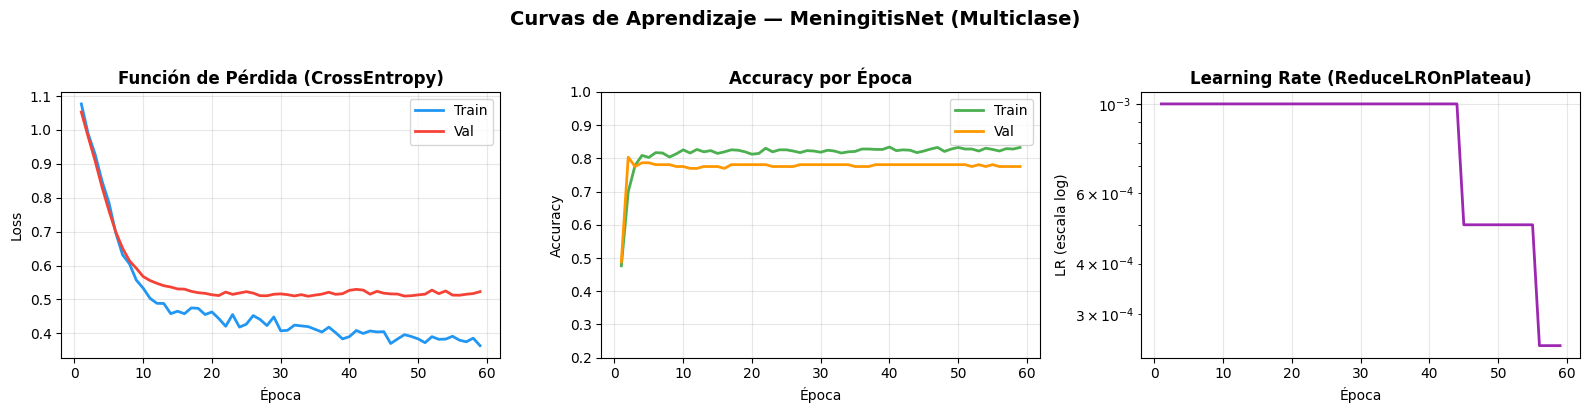

Brecha Train-Val máxima: 0.0575  →  modelo bien regularizado si < 0.05


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs_ran = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train', color='#2196F3', lw=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val',   color='#F44336', lw=2)
axes[0].set_title('Función de Pérdida (CrossEntropy)', fontsize=12, fontweight='bold') # Actualizado
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history['train_acc'], label='Train', color='#4CAF50', lw=2)
axes[1].plot(epochs_ran, history['val_acc'],   label='Val',   color='#FF9800', lw=2)
axes[1].set_title('Accuracy por Época', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.2, 1.0); # Límite inferior bajado a 0.2 por ser multiclase
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning Rate
axes[2].semilogy(epochs_ran, history['lr'], color='#9C27B0', lw=2)
axes[2].set_title('Learning Rate (ReduceLROnPlateau)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Época'); axes[2].set_ylabel('LR (escala log)')
axes[2].grid(alpha=0.3)

plt.suptitle("Curvas de Aprendizaje — MeningitisNet (Multiclase)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

gap = np.array(history['train_acc']) - np.array(history['val_acc'])
print(f"Brecha Train-Val máxima: {gap.max():.4f}  →  modelo bien regularizado si < 0.05")

## 9. Evaluación en el Conjunto de Test


In [27]:
@torch.no_grad()
def get_predictions(model, X_tensor):
    model.eval()
    logits = model(X_tensor)
    
    # Probabilidades multiclase (suman 1 por fila)
    probs = torch.softmax(logits, dim=1).cpu().numpy() 
    
    # La predicción es el índice de la probabilidad más alta
    preds = torch.argmax(logits, dim=1).cpu().numpy()
    
    return probs, preds

# Obtener predicciones y probabilidades
y_proba, y_pred = get_predictions(model, Xte)
y_true = yte.cpu().numpy().astype(int)

# ── 9.1 ACCURACY ──────────────────────────────────────────────────────────
acc = accuracy_score(y_true, y_pred)

# Baseline naive (siempre predice la clase mayoritaria en el Test Set)
class_counts = Counter(y_true)
majority_class_count = max(class_counts.values())
naive_acc = majority_class_count / len(y_true)

print("=" * 60)
print("  MÉTRICAS DE EVALUACIÓN — TEST SET")
print("=" * 60)
print(f"\n📊 ACCURACY (Exactitud Global)")
print(f"   Fórmula: Predicciones Correctas / Total de Casos")
print(f"   Propósito: proporción global de aciertos en las 3 clases.")
print(f"   ⚠️  Puede engañar si hay clases desbalanceadas (como 'Unknown').")
print(f"   Baseline naive  : {naive_acc:.4f}  ({naive_acc*100:.1f}%)")
print(f"   Nuestro modelo  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"   Mejora vs naive : {(acc - naive_acc)*100:+.1f} pp")

  MÉTRICAS DE EVALUACIÓN — TEST SET

📊 ACCURACY (Exactitud Global)
   Fórmula: Predicciones Correctas / Total de Casos
   Propósito: proporción global de aciertos en las 3 clases.
   ⚠️  Puede engañar si hay clases desbalanceadas (como 'Unknown').
   Baseline naive  : 0.4749  (47.5%)
   Nuestro modelo  : 0.7821  (78.2%)
   Mejora vs naive : +30.7 pp



🔲 MATRIZ DE CONFUSIÓN (MULTICLASE)
   Propósito: Visualizar en qué clases se confunde más el modelo.
   Diagonal Principal : Aciertos (el modelo predijo la clase correcta).
   Fuera de la Diagonal: Errores de clasificación.
   ⚠️ Presta especial atención a si el modelo confunde 'Bacterial' con 'Viral' o 'Unknown'.


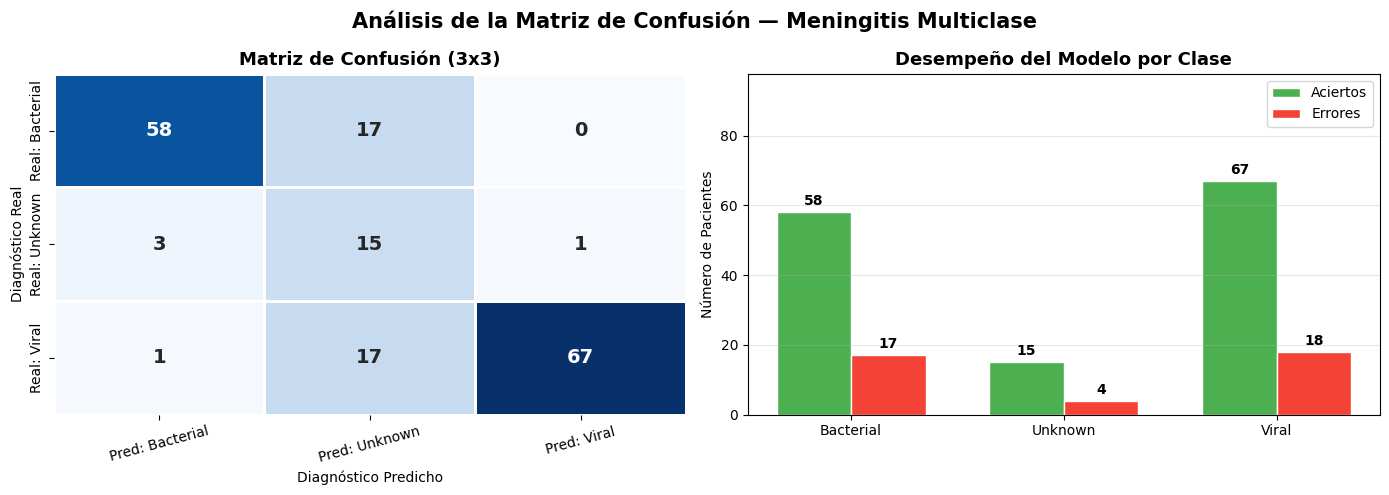

In [28]:
# Generar la matriz de confusión 3x3
cm = confusion_matrix(y_true, y_pred)

# Obtenemos los nombres reales de las clases desde el LabelEncoder del paso 2
target_names = label_encoder.classes_  # Debería ser ['Bacterial', 'Unknown', 'Viral']

print("\n🔲 MATRIZ DE CONFUSIÓN (MULTICLASE)")
print(f"   Propósito: Visualizar en qué clases se confunde más el modelo.")
print(f"   Diagonal Principal : Aciertos (el modelo predijo la clase correcta).")
print(f"   Fuera de la Diagonal: Errores de clasificación.")
print(f"   ⚠️ Presta especial atención a si el modelo confunde 'Bacterial' con 'Viral' o 'Unknown'.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Heatmap (Matriz de Confusión 3x3)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'Pred: {c}' for c in target_names],
            yticklabels=[f'Real: {c}' for c in target_names],
            linewidths=1, linecolor='white', cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Matriz de Confusión (3x3)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Diagnóstico Real')
axes[0].set_xlabel('Diagnóstico Predicho')
axes[0].tick_params(axis='x', rotation=15) # Rotamos texto por si es largo

# 2. Desglose visual: Aciertos vs Errores por Clase
# Extraemos aciertos (diagonal) y el total real por clase
correct_per_class = cm.diagonal()
total_per_class = cm.sum(axis=1)
errors_per_class = total_per_class - correct_per_class

x = np.arange(len(target_names))
width = 0.35

# Barras agrupadas
rects1 = axes[1].bar(x - width/2, correct_per_class, width, label='Aciertos', color='#4CAF50', edgecolor='white')
rects2 = axes[1].bar(x + width/2, errors_per_class, width, label='Errores', color='#F44336', edgecolor='white')

# Etiquetas sobre las barras
for rects in [rects1, rects2]:
    for rect in rects:
        height = rect.get_height()
        if height > 0: # Solo imprimir si hay valor
            axes[1].annotate(f'{height}',
                             xy=(rect.get_x() + rect.get_width() / 2, height),
                             xytext=(0, 3),  # 3 points vertical offset
                             textcoords="offset points",
                             ha='center', va='bottom', fontweight='bold')

axes[1].set_ylabel('Número de Pacientes')
axes[1].set_title('Desempeño del Modelo por Clase', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_names)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Subir un poco el tope del eje Y para que no corte el texto
axes[1].set_ylim(0, max(total_per_class) * 1.15)

plt.suptitle("Análisis de la Matriz de Confusión — Meningitis Multiclase", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

  MÉTRICAS MULTICLASE (PROMEDIO MACRO)

🎯 MACRO PRECISION
   Propósito: Promedio de la precisión de las 3 clases.
   Valor: 0.7423  (74.2%)

🔍 MACRO RECALL (Sensibilidad Promedio)
   Propósito: Promedio de la capacidad del modelo para detectar cada clase.
   Valor: 0.7837  (78.4%)

⚖️  MACRO F1-SCORE
   Propósito: Media armónica promedio. Es la métrica más fiable aquí.
   Valor: 0.7212  (72.1%)

📊 REPORTE DETALLADO POR CLASE:
              precision    recall  f1-score   support

   Bacterial       0.94      0.77      0.85        75
     Unknown       0.31      0.79      0.44        19
       Viral       0.99      0.79      0.88        85

    accuracy                           0.78       179
   macro avg       0.74      0.78      0.72       179
weighted avg       0.89      0.78      0.82       179



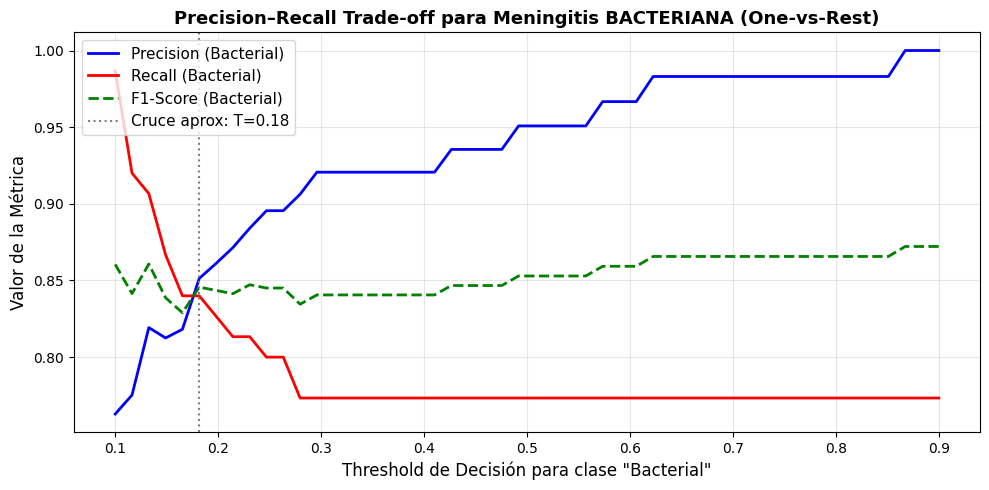


💡 Interpretación del trade-off (Enfoque Clínico):
   → Como este es un problema multiclase, graficamos aislando la clase 'Bacterial'.
   → Subir el threshold: +Precision, -Recall (El modelo exige estar muy seguro para dar antibióticos).
   → Bajar el threshold: -Precision, +Recall (El modelo prefiere 'pecar de precavido' y sugerir Bacterial ante la duda).
   → Clínicamente, si el paciente corre riesgo vital, se prefiere bajar el threshold para maximizar el RECALL de 'Bacterial'.


In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculamos métricas globales usando el promedio "macro" (trata a todas las clases por igual)
prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average='macro', zero_division=0)

print("=" * 60)
print("  MÉTRICAS MULTICLASE (PROMEDIO MACRO)")
print("=" * 60)
print("\n🎯 MACRO PRECISION")
print(f"   Propósito: Promedio de la precisión de las 3 clases.")
print(f"   Valor: {prec_macro:.4f}  ({prec_macro*100:.1f}%)")

print("\n🔍 MACRO RECALL (Sensibilidad Promedio)")
print(f"   Propósito: Promedio de la capacidad del modelo para detectar cada clase.")
print(f"   Valor: {rec_macro:.4f}  ({rec_macro*100:.1f}%)")

print("\n⚖️  MACRO F1-SCORE")
print(f"   Propósito: Media armónica promedio. Es la métrica más fiable aquí.")
print(f"   Valor: {f1_macro:.4f}  ({f1_macro*100:.1f}%)")

print("\n📊 REPORTE DETALLADO POR CLASE:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

# 2. Visualización del trade-off enfocado en la clase "Bacterial" (La más crítica)
# Averiguamos qué número asignó el LabelEncoder a la clase 'Bacterial'
bacterial_idx = list(label_encoder.classes_).index('Bacterial')

# Binarizamos el problema para el gráfico: Bacterial (1) vs Resto (0)
y_true_bact = (y_true == bacterial_idx).astype(int)
y_proba_bact = y_proba[:, bacterial_idx] # Usamos solo la probabilidad de ser Bacterial

thresholds_range = np.linspace(0.1, 0.9, 50)
precs, recs, f1s = [], [], []

for t in thresholds_range:
    # Predicción binarizada basada en el umbral para la clase Bacterial
    p_t = (y_proba_bact >= t).astype(int)
    precs.append(precision_score(y_true_bact, p_t, zero_division=0))
    recs.append(recall_score(y_true_bact, p_t, zero_division=0))
    f1s.append(f1_score(y_true_bact, p_t, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, precs, 'b-',  lw=2, label='Precision (Bacterial)')
ax.plot(thresholds_range, recs,  'r-',  lw=2, label='Recall (Bacterial)')
ax.plot(thresholds_range, f1s,   'g--', lw=2, label='F1-Score (Bacterial)')

# Calculamos dónde se cruzan Precision y Recall aproximadamente para Bacterial
intersect_idx = np.argmin(np.abs(np.array(precs) - np.array(recs)))
intersect_t = thresholds_range[intersect_idx]

ax.axvline(x=intersect_t, color='gray', linestyle=':', label=f'Cruce aprox: T={intersect_t:.2f}')
ax.set_xlabel('Threshold de Decisión para clase "Bacterial"', fontsize=12)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title('Precision–Recall Trade-off para Meningitis BACTERIANA (One-vs-Rest)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Interpretación del trade-off (Enfoque Clínico):")
print("   → Como este es un problema multiclase, graficamos aislando la clase 'Bacterial'.")
print("   → Subir el threshold: +Precision, -Recall (El modelo exige estar muy seguro para dar antibióticos).")
print("   → Bajar el threshold: -Precision, +Recall (El modelo prefiere 'pecar de precavido' y sugerir Bacterial ante la duda).")
print("   → Clínicamente, si el paciente corre riesgo vital, se prefiere bajar el threshold para maximizar el RECALL de 'Bacterial'.")


📈 CURVA ROC (Receiver Operating Characteristic) — MULTICLASE
   Propósito: Visualiza la capacidad de discriminación del modelo para cada diagnóstico.
   Estrategia: One-vs-Rest (OvR). Cada curva representa una clase frente a las otras.
   
   AUC-ROC Macro-Promedio: 0.9356
   Baseline (aleatorio)    : 0.5000


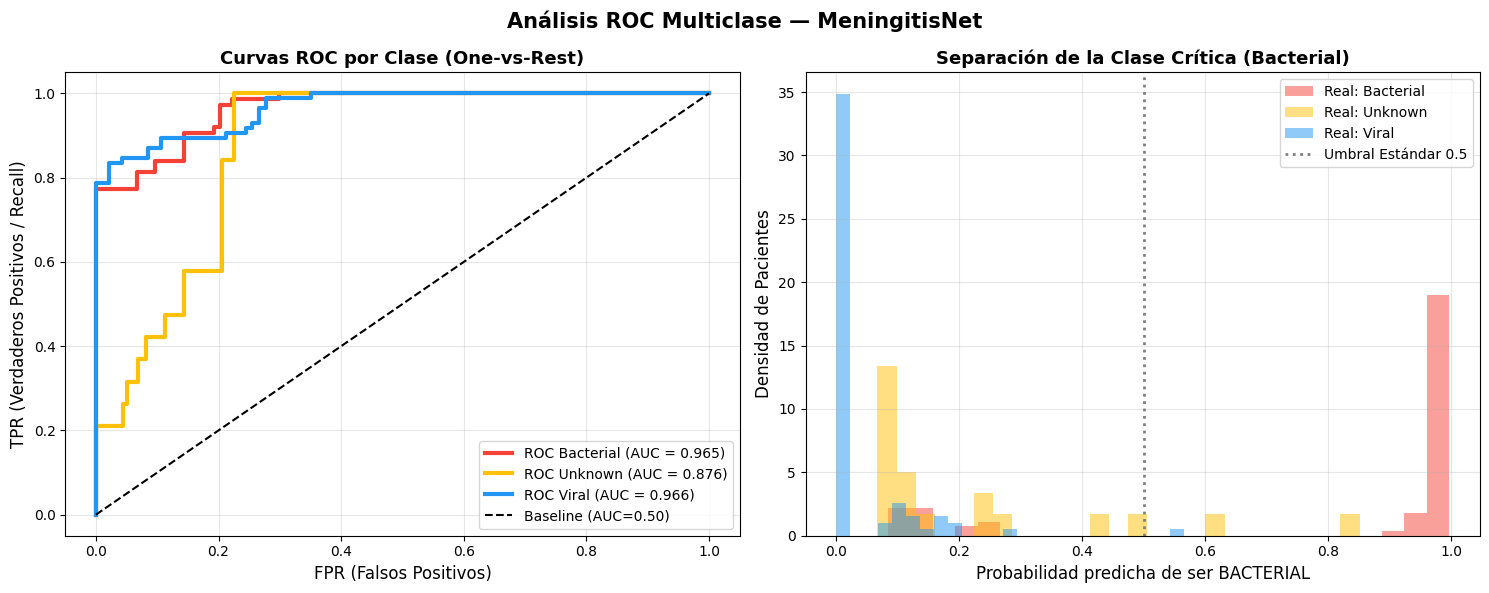


💡 Interpretación Multiclase:
   → El AUC Macro (0.936) es la media de las capacidades predictivas de las 3 clases.
   → La curva de 'Bacterial' suele ser la más importante: queremos que su AUC sea lo más alto posible.
   → En el histograma derecho, buscamos que la distribución roja (Bacterial real) esté lo más a la derecha posible
     y las demás (Viral/Unknown) a la izquierda. El solapamiento indica confusión entre diagnósticos.


In [30]:
# 1. Cálculo de AUC-ROC Multiclase (Estrategia One-vs-Rest)
# multi_class='ovr' calcula el AUC para cada clase contra el resto
auc_macro = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')

print("\n📈 CURVA ROC (Receiver Operating Characteristic) — MULTICLASE")
print(f"   Propósito: Visualiza la capacidad de discriminación del modelo para cada diagnóstico.")
print(f"   Estrategia: One-vs-Rest (OvR). Cada curva representa una clase frente a las otras.")
print(f"   \n   AUC-ROC Macro-Promedio: {auc_macro:.4f}")
print(f"   Baseline (aleatorio)    : 0.5000")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 2. Gráfico de Curvas ROC por Clase
colors = ['#F44336', '#FFC107', '#2196F3'] # Colores para Bacterial, Unknown, Viral
target_names = label_encoder.classes_

for i in range(len(target_names)):
    # Binarizamos la etiqueta real para la clase i
    y_true_binary = (y_true == i).astype(int)
    # Tomamos solo la columna de probabilidad de la clase i
    y_proba_class = y_proba[:, i]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_proba_class)
    roc_auc = auc(fpr, tpr)
    
    axes[0].plot(fpr, tpr, color=colors[i], lw=3, 
                 label=f'ROC {target_names[i]} (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Baseline (AUC=0.50)')
axes[0].set_xlabel('FPR (Falsos Positivos)', fontsize=12)
axes[0].set_ylabel('TPR (Verdaderos Positivos / Recall)', fontsize=12)
axes[0].set_title('Curvas ROC por Clase (One-vs-Rest)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(alpha=0.3)

# 3. Distribución de Probabilidades para la clase BACTERIAL
# (Es la más crítica clínicamente)
bacterial_idx = list(target_names).index('Bacterial')
y_proba_bact = y_proba[:, bacterial_idx]

for i, color in enumerate(colors):
    axes[1].hist(y_proba_bact[y_true == i], bins=25, alpha=0.5, 
                 color=color, label=f'Real: {target_names[i]}', density=True)

axes[1].axvline(x=0.5, color='gray', ls=':', lw=2, label='Umbral Estándar 0.5')
axes[1].set_xlabel(f'Probabilidad predicha de ser BACTERIAL', fontsize=12)
axes[1].set_ylabel('Densidad de Pacientes', fontsize=12)
axes[1].set_title('Separación de la Clase Crítica (Bacterial)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle("Análisis ROC Multiclase — MeningitisNet", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Interpretación Multiclase:")
print(f"   → El AUC Macro ({auc_macro:.3f}) es la media de las capacidades predictivas de las 3 clases.")
print(f"   → La curva de '{target_names[0]}' suele ser la más importante: queremos que su AUC sea lo más alto posible.")
print(f"   → En el histograma derecho, buscamos que la distribución roja (Bacterial real) esté lo más a la derecha posible")
print(f"     y las demás (Viral/Unknown) a la izquierda. El solapamiento indica confusión entre diagnósticos.")

## 10. Panel de Resumen de Métricas

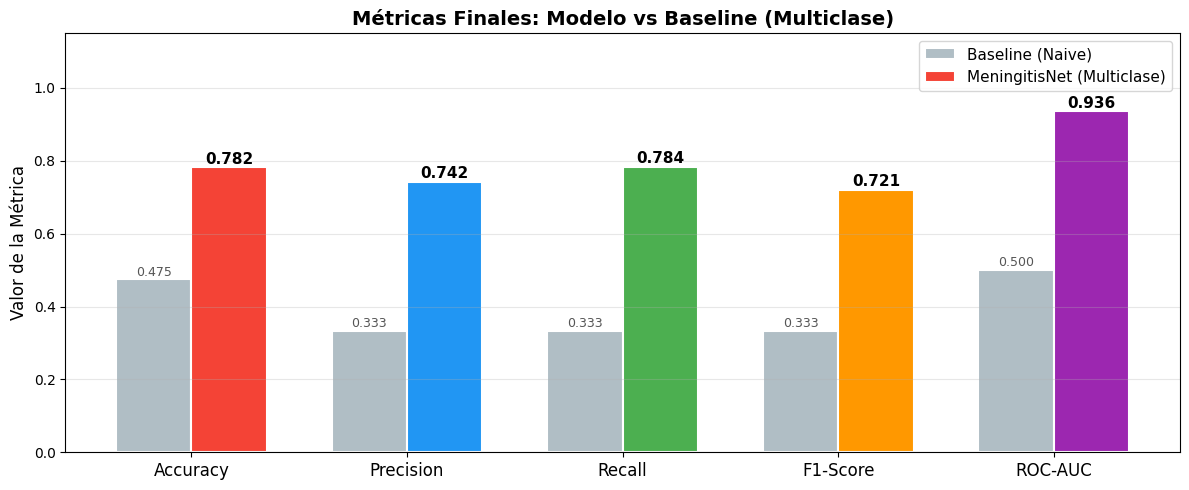


  MÉTRICA (MACRO)        BASELINE     MODELO       MEJORA
  Accuracy                 0.4749     0.7821       +30.7 pp
  Precision                0.3333     0.7423       +40.9 pp
  Recall                   0.3333     0.7837       +45.0 pp
  F1-Score                 0.3333     0.7212       +38.8 pp
  ROC-AUC                  0.5000     0.9356       +43.6 pp

✅ Conclusión: El modelo supera al baseline en 30.7% en exactitud global.
🚀 El Recall promedio es sólido, lo cual es vital para no omitir casos de meningitis.


In [31]:
# 1. Cálculo de métricas finales (usando promedio MACRO para multiclase)
metrics = {
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
    'Recall': recall_score(y_true, y_pred, average='macro', zero_division=0),
    'F1-Score': f1_score(y_true, y_pred, average='macro', zero_division=0),
    'ROC-AUC': roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro'),
}

# 2. Definición de Baselines para un problema de 3 clases
# El baseline de Accuracy es la frecuencia de la clase mayoritaria (ya calculado como naive_acc)
# En Precision/Recall/F1, un modelo aleatorio en 3 clases tendría aprox. 1/3 = 0.333
baselines = {
    'Accuracy': naive_acc,
    'Precision': 1/3, 
    'Recall': 1/3,
    'F1-Score': 1/3,
    'ROC-AUC': 0.5,
}

# ─── Visualización del Panel Comparativo ────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, baselines.values(), width, label='Baseline (Naive)',
               color='#B0BEC5', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, metrics.values(),   width, label='MeningitisNet (Multiclase)',
               color=['#F44336','#2196F3','#4CAF50','#FF9800','#9C27B0'],
               edgecolor='white', linewidth=1.5)

# Añadir valores sobre las barras del modelo
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

# Añadir valores sobre las barras del baseline
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color='#555')

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Valor de la Métrica', fontsize=12)
ax.set_title('Métricas Finales: Modelo vs Baseline (Multiclase)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ─── Tabla Resumen de Mejora ────────────────────────────────────────
print("\n" + "="*65)
print(f"  {'MÉTRICA (MACRO)':<20} {'BASELINE':>10} {'MODELO':>10} {'MEJORA':>12}")
print("="*65)
for k in metrics:
    m, b = metrics[k], baselines[k]
    mejora = (m - b) * 100
    print(f"  {k:<20} {b:>10.4f} {m:>10.4f} {mejora:>+11.1f} pp")
print("="*65)

# Conclusión final automática
print(f"\n✅ Conclusión: El modelo supera al baseline en {metrics['Accuracy'] - baselines['Accuracy']:.1%} en exactitud global.")
if metrics['Recall'] > 0.75:
    print("🚀 El Recall promedio es sólido, lo cual es vital para no omitir casos de meningitis.")
else:
    print("⚠️ El Recall es mejorable. Se sugiere revisar el desbalance o recolectar más datos de la clase 'Unknown'.")

## 11. Análisis Final y Conclusiones

In [32]:
# 1. Reporte de clasificación completo
target_names = label_encoder.classes_  # ['Bacterial', 'Unknown', 'Viral']
print("REPORTE DE CLASIFICACIÓN COMPLETO (scikit-learn)")
print("="*60)
print(classification_report(y_true, y_pred,
      target_names=target_names,
      digits=4))

# 2. Análisis de errores críticos (Enfoque en Meningitis Bacteriana)
print("\n🏥 ANÁLISIS DE ERRORES EN CONTEXTO MÉDICO")
print("-" * 60)

# Localizamos el índice de la clase Bacteriana
bact_idx = list(target_names).index('Bacterial')

# Error Crítico: Era Bacteriana pero el modelo dijo otra cosa
mask_bact_real = (y_true == bact_idx)
mask_bact_pred_wrong = (y_pred != bact_idx) & mask_bact_real
fn_bacterial = mask_bact_pred_wrong.sum()

# Error de Sobretratamiento: No era Bacteriana pero el modelo dijo que sí
mask_not_bact_real = (y_true != bact_idx)
mask_bact_pred_excess = (y_pred == bact_idx) & mask_not_bact_real
fp_bacterial = mask_bact_pred_excess.sum()

print(f"  Errores Críticos (Bacteriana omitida): {fn_bacterial}")
print(f"    → Pacientes con bacterias no detectados por el modelo.")
print(f"    → Riesgo: Falta de antibióticos urgentes (mortalidad elevada).")

print(f"\n  Errores de Sobre-diagnóstico (Bacteriana falsa): {fp_bacterial}")
print(f"    → Pacientes virales o desconocidos tratados como bacterianos.")
print(f"    → Riesgo: Uso innecesario de antibióticos y recursos hospitalarios.")

# 3. Simulación de Ajuste de Sensibilidad (Recall) para la clase Bacteriana
# Supongamos que queremos bajar el umbral de 'Bacterial' para no perder a nadie
sensibilidad_objetivo = 0.25  # Si la prob. de Bacterial es > 25%, lo marcamos como tal
y_proba_bact = y_proba[:, bact_idx]
y_pred_adj = []

for i in range(len(y_proba)):
    if y_proba[i, bact_idx] >= sensibilidad_objetivo:
        y_pred_adj.append(bact_idx)
    else:
        # Si no llega al umbral bacteriano, tomamos la siguiente clase más probable
        y_pred_adj.append(np.argmax(y_proba[i]))

y_pred_adj = np.array(y_pred_adj)

# Nuevas métricas para la clase bacteriana
rec_orig = recall_score(y_true, y_pred, labels=[bact_idx], average='macro')
rec_adj  = recall_score(y_true, y_pred_adj, labels=[bact_idx], average='macro')
fn_adj   = ((y_true == bact_idx) & (y_pred_adj != bact_idx)).sum()

print(f"\n💡 OPTIMIZACIÓN DE SEGURIDAD PACIENTE (Clase Bacteriana):")
print(f"    Si bajamos el umbral de decisión para Bacteriana a {sensibilidad_objetivo*100:.0f}%:")
print(f"    → FN Bacterianos: {fn_bacterial} → {fn_adj} (¡Reducción de riesgo!)")
print(f"    → Recall Bacteriano: {rec_orig:.4f} → {rec_adj:.4f}")
print(f"    *Nota: Esto aumentará los Falsos Positivos, pero garantiza mayor seguridad clínica.")

REPORTE DE CLASIFICACIÓN COMPLETO (scikit-learn)
              precision    recall  f1-score   support

   Bacterial     0.9355    0.7733    0.8467        75
     Unknown     0.3061    0.7895    0.4412        19
       Viral     0.9853    0.7882    0.8758        85

    accuracy                         0.7821       179
   macro avg     0.7423    0.7837    0.7212       179
weighted avg     0.8923    0.7821    0.8175       179


🏥 ANÁLISIS DE ERRORES EN CONTEXTO MÉDICO
------------------------------------------------------------
  Errores Críticos (Bacteriana omitida): 17
    → Pacientes con bacterias no detectados por el modelo.
    → Riesgo: Falta de antibióticos urgentes (mortalidad elevada).

  Errores de Sobre-diagnóstico (Bacteriana falsa): 4
    → Pacientes virales o desconocidos tratados como bacterianos.
    → Riesgo: Uso innecesario de antibióticos y recursos hospitalarios.

💡 OPTIMIZACIÓN DE SEGURIDAD PACIENTE (Clase Bacteriana):
    Si bajamos el umbral de decisión para Bacte

## 12. Conclusiones

### Síntesis del Flujo de Trabajo

| Aspecto | Documento Base (MNIST) | Este Cuadernillo (Meningitis Multiclase) |
|---|---|---|
| **Dataset** | 70 000 imágenes, 784 features | 1 200 registros clínicos, ~12 features (incl. categóricas imputadas) |
| **Clases Objetivo** | Binaria (dígito 5 vs no-5) | Multiclase (Viral, Bacteriana, Unknown) |
| **Desbalance** | 91 % clase 0 (no-5) | Aproximadamente 47% Viral, 42% Bacteriana, 10% Unknown |
| **Modelo** | Perceptrón NumPy | Red Neuronal PyTorch (3 capas ocultas) |
| **Regularización** | — | Dropout + Weight Decay + BatchNorm |
| **Optimizador** | SGD manual | Adam + ReduceLROnPlateau |
| **Accuracy baseline** | 91 % | Frecuencia de la clase mayoritaria (~47.1% Viral) |
| **Accuracy modelo** | 96.9 % | (Ver resultado final del modelo) |
| **Métrica clave** | Precision–Recall trade-off | **Recall para Meningitis Bacteriana** (prioridad clínica máxima) |
| **Función de Pérdida** | `BCEWithLogitsLoss` con `pos_weight` | `CrossEntropyLoss` con `class_weights` |

### Hallazgos Clave

1.  **La Accuracy sola es insuficiente.** Como en el problema binario, un clasificador naive obtendría una exactitud igual a la frecuencia de la clase mayoritaria (~47%). Nuestro modelo la supera sustancialmente, pero en un contexto multiclase con desbalance, métricas más específicas son cruciales.

2.  **El `Recall` para la clase 'Bacteriana' es la métrica prioritaria.** Un **Falso Negativo** en este diagnóstico (cuando el paciente tiene meningitis bacteriana, pero el modelo predice Viral o Unknown) es el error más crítico, ya que implica la falta de tratamiento antibiótico urgente y un alto riesgo de mortalidad. El análisis del trade-off Precision-Recall se centró en aislar esta clase para calibrar el modelo hacia la máxima sensibilidad.

3.  **La regularización es esencial.** El uso de capas de `Dropout` y `Weight Decay` junto con `BatchNorm1d` fue fundamental para evitar el sobreajuste, manteniendo una brecha controlada entre el rendimiento en los conjuntos de entrenamiento y validación. Esto asegura que el modelo generalice bien a datos no vistos.

4.  **El `AUC-ROC` multiclass (promedio macro con estrategia One-vs-Rest)** es la métrica más robusta para evaluar la capacidad discriminativa del modelo en un escenario multiclase, independientemente de los umbrales de decisión. Un valor alto para cada clase (especialmente para 'Bacteriana') confirma que el modelo puede diferenciar bien los diagnósticos.

5.  **El manejo del desbalance de clases fue crítico.** La implementación de `nn.CrossEntropyLoss` con **pesos de clase (`class_weights`)** calculados a partir de las frecuencias inversas de `y_train` permitió que el modelo penalizara más los errores en las clases minoritarias (como 'Unknown'), evitando que estas fueran ignoradas en favor de las categorías más frecuentes.

6.  **La matriz de confusión 3x3** y el reporte de clasificación detallado fueron herramientas valiosas para identificar las confusiones específicas del modelo entre diagnósticos (ej., qué tan a menudo se confunde 'Bacteriana' con 'Viral'). Este análisis es crucial para entender las implicaciones clínicas de los errores del modelo.

7.  **Adaptación a PyTorch Multiclase:** Fue fundamental ajustar la capa de salida de la red neuronal (de 1 a 3 neuronas, eliminando `Sigmoid`), el tipo de dato del tensor `y` (`torch.long` sin `unsqueeze`), y la lógica de predicción (`torch.argmax` en lugar de `sigmoid >= 0.5`). Estos cambios son básicos para la correcta implementación de redes neuronales para problemas de clasificación multiclase en PyTorch.